# B-4064A - diagnostico do resultado fraco/incerto

**Status atual:** re-baselinar por mudanca de regime termico em 2025.

Objetivo: documentar por que o modelo tende a render pouco antes de gastar mais tuning. A analise mede sensores mortos, pobreza de dados em operacao, bimodalidade ligado/desligado, mudanca de regime e separabilidade normal vs pre-falha com uma meta simples de 1% FP.

In [1]:

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.covariance import LedoitWolf
from sklearn.mixture import GaussianMixture

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()), Path.cwd())
sys.path.insert(0, str(ROOT / "src"))

from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.loading import load_equipment_data
from transpetro_modelos.data.preprocessing import run_preprocessing

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 80)
pd.set_option("display.max_columns", 80)


In [2]:

EQUIPMENT = "B-4064A"
CONFIG_KEY = "B-4064A-prod"
FAILURE_DATE = pd.Timestamp("2024-08-30 07:58")
STATUS_ATUAL = "re-baselinar por mudanca de regime termico em 2025"
FALLBACK_FILES = ['Dados-novos/B-4064A_novos.feather']

def _read_any(path):
    path = Path(path)
    if path.suffix == ".feather":
        return pd.read_feather(path)
    return pd.read_csv(path)

def _ensure_datetime_index(df, datetime_column=None):
    if isinstance(df.index, pd.DatetimeIndex):
        return df.sort_index()
    candidates = []
    if datetime_column:
        candidates.append(datetime_column)
    candidates.extend(["datetime", "Timestamp", "Data Hora", "data_hora", "DataHora"])
    for col in candidates:
        if col in df.columns:
            out = df.set_index(col)
            out.index = pd.to_datetime(out.index)
            return out.sort_index()
    first = df.columns[0]
    parsed = pd.to_datetime(df[first], errors="coerce")
    if parsed.notna().mean() > 0.8:
        out = df.set_index(first)
        out.index = pd.to_datetime(out.index)
        return out.sort_index()
    raise ValueError("Nao encontrei coluna temporal clara.")

def load_data():
    cfg = EQUIPMENT_CONFIGS.get(CONFIG_KEY)
    try:
        df = load_equipment_data(CONFIG_KEY, from_clearml=False)
        return df, f"config:{CONFIG_KEY}"
    except Exception as exc:
        print(f"load_equipment_data falhou para {CONFIG_KEY}: {type(exc).__name__}: {exc}")
    for rel in FALLBACK_FILES:
        path = ROOT / rel
        if path.exists():
            df = _read_any(path)
            dt_col = cfg.datetime_column if cfg else None
            return _ensure_datetime_index(df, dt_col), str(rel)
    raise FileNotFoundError(f"Nenhum fallback encontrado: {FALLBACK_FILES}")

def numeric_live(df):
    num = df.select_dtypes(include=[np.number]).copy()
    rows = []
    for col in num.columns:
        s = num[col]
        nn = int(s.notna().sum())
        zero_frac = float((s.fillna(0) == 0).mean()) if len(s) else 0.0
        rows.append({
            "sensor": col,
            "n_validos": nn,
            "missing_pct": float(s.isna().mean()),
            "zero_pct": zero_frac,
            "std": float(s.std(skipna=True)) if nn else np.nan,
            "min": float(s.min(skipna=True)) if nn else np.nan,
            "p50": float(s.median(skipna=True)) if nn else np.nan,
            "max": float(s.max(skipna=True)) if nn else np.nan,
        })
    q = pd.DataFrame(rows)
    dead_mask = (q["n_validos"] == 0) | (q["std"].fillna(0) == 0) | (q["zero_pct"] >= 0.995)
    dead = q.loc[dead_mask, "sensor"].tolist()
    live = num.drop(columns=dead, errors="ignore")
    return num, live, q.sort_values(["zero_pct", "missing_pct"], ascending=False), dead

def pick_activity(live):
    preferred = ("corrente", "current", "vaz", "flow", "pressao descarga", "pressão descarga")
    for kw in preferred:
        cand = [c for c in live.columns if kw in c.lower()]
        if cand:
            return max(cand, key=lambda c: live[c].quantile(0.99) - live[c].quantile(0.01))
    spread = live.quantile(0.99) - live.quantile(0.01)
    return spread.idxmax()

def activity_cutoff(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) < 200 or x.nunique() < 10:
        return None, None, False, None
    arr = x.to_numpy().reshape(-1, 1)
    g1 = GaussianMixture(1, random_state=0).fit(arr)
    g2 = GaussianMixture(2, random_state=0).fit(arr)
    means = np.sort(g2.means_.ravel())
    stds = np.sqrt(g2.covariances_.ravel())
    gap = abs(means[1] - means[0]) / max(float(np.max(stds)), 1e-9)
    bimodal = (g2.bic(arr) + 10 < g1.bic(arr)) and gap > 2.0
    if not bimodal:
        return None, means, False, gap
    grid = np.linspace(means[0], means[1], 500).reshape(-1, 1)
    cutoff = float(grid[np.argmin(np.exp(g2.score_samples(grid)))][0])
    off_frac = float((x < cutoff).mean())
    return cutoff, means, off_frac, gap

def robust_z(frame, normal):
    med = normal.median()
    mad = (normal - med).abs().median().replace(0, np.nan)
    scale = 1.4826 * mad
    return (frame - med) / scale

raw, source = load_data()
cfg = EQUIPMENT_CONFIGS.get(CONFIG_KEY)
print(f"{EQUIPMENT} | status: {STATUS_ATUAL}")
print(f"Fonte usada: {source}")
print(f"Periodo bruto: {raw.index.min()} -> {raw.index.max()} | linhas={len(raw):,} | colunas={raw.shape[1]}")
print(f"Falha conhecida: {FAILURE_DATE}")
if not (raw.index.min() <= FAILURE_DATE <= raw.index.max()):
    print("ATENCAO: data da falha esta fora do periodo do arquivo carregado.")

num, live, quality, dead = numeric_live(raw)
print(f"Sensores numericos: {num.shape[1]} | vivos: {live.shape[1]} | mortos/quase mortos: {len(dead)}")
if dead:
    print("Mortos/quase mortos:", dead)
display(quality.head(30).style.format({
    "missing_pct": "{:.1%}", "zero_pct": "{:.1%}", "std": "{:.4g}",
    "min": "{:.4g}", "p50": "{:.4g}", "max": "{:.4g}",
}))

if cfg is not None and getattr(cfg, "pre_split_steps", None):
    try:
        proc_pre, _, report = run_preprocessing(
            raw.copy(), cfg.pre_split_steps, return_artifacts=True, return_report=True
        )
        print(
            f"Depois do pre_split_steps da config: {len(proc_pre):,} linhas "
            f"({len(proc_pre) / max(len(raw), 1):.1%} do bruto), colunas={proc_pre.shape[1]}"
        )
    except Exception as exc:
        proc_pre = None
        print(f"Nao consegui aplicar pre_split_steps da config: {type(exc).__name__}: {exc}")
else:
    proc_pre = None
    print("Config sem pre_split_steps; analise segue no bruto numerico.")


B-4064A | status: re-baselinar por mudanca de regime termico em 2025
Fonte usada: config:B-4064A-prod
Periodo bruto: 2024-01-01 01:00:00 -> 2026-03-27 08:29:00 | linhas=43,220 | colunas=8
Falha conhecida: 2024-08-30 07:58:00
Sensores numericos: 8 | vivos: 8 | mortos/quase mortos: 0


,sensor,n_validos,missing_pct,zero_pct,std,min,p50,max
7,Vibração Bomba LNA,6542,84.9%,84.9%,1.548,-3.175,1.021,11.27
3,Temperatura Bomba LA,6925,84.0%,84.0%,11.3,-25,39.08,138.8
5,Temperatura Motor LA,6928,84.0%,84.0%,21.43,-25,68.92,85.4
6,Temperatura Motor LNA,7067,83.6%,83.6%,17.66,-25,62.92,76.36
4,Temperatura Bomba LNA,7314,83.1%,83.1%,17.16,-25,45,138.8
0,Corrente,7618,82.4%,82.4%,20.58,-24.87,36.35,100.5
2,Pressão Sucção,9687,77.6%,77.6%,2.77,-12.5,6.42,16.9
1,Pressão Descarga,12511,71.1%,71.1%,13.25,-22.5,28.62,40.64


Depois do pre_split_steps da config: 11,694 linhas (27.1% do bruto), colunas=8


Sensor de atividade escolhido: Corrente
Sem bimodalidade clara para ligado/desligado; usando todos os pontos vivos.
Amostras em operacao usadas na separabilidade: 11,694 (100.0% dos pontos vivos)


/tmp/ipykernel_36277/2410235956.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


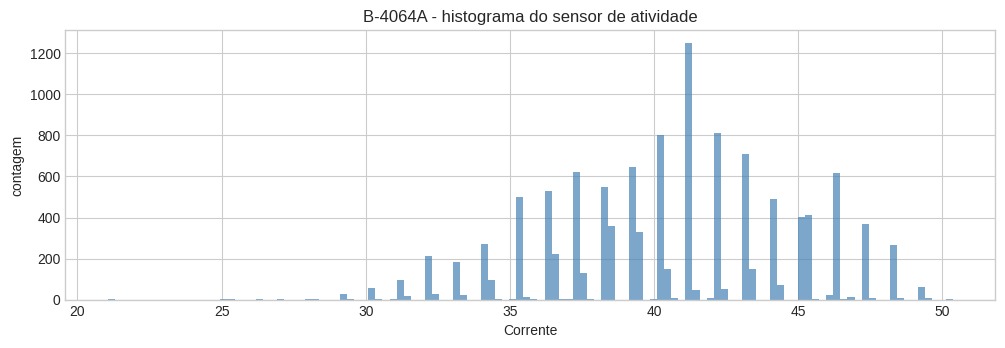

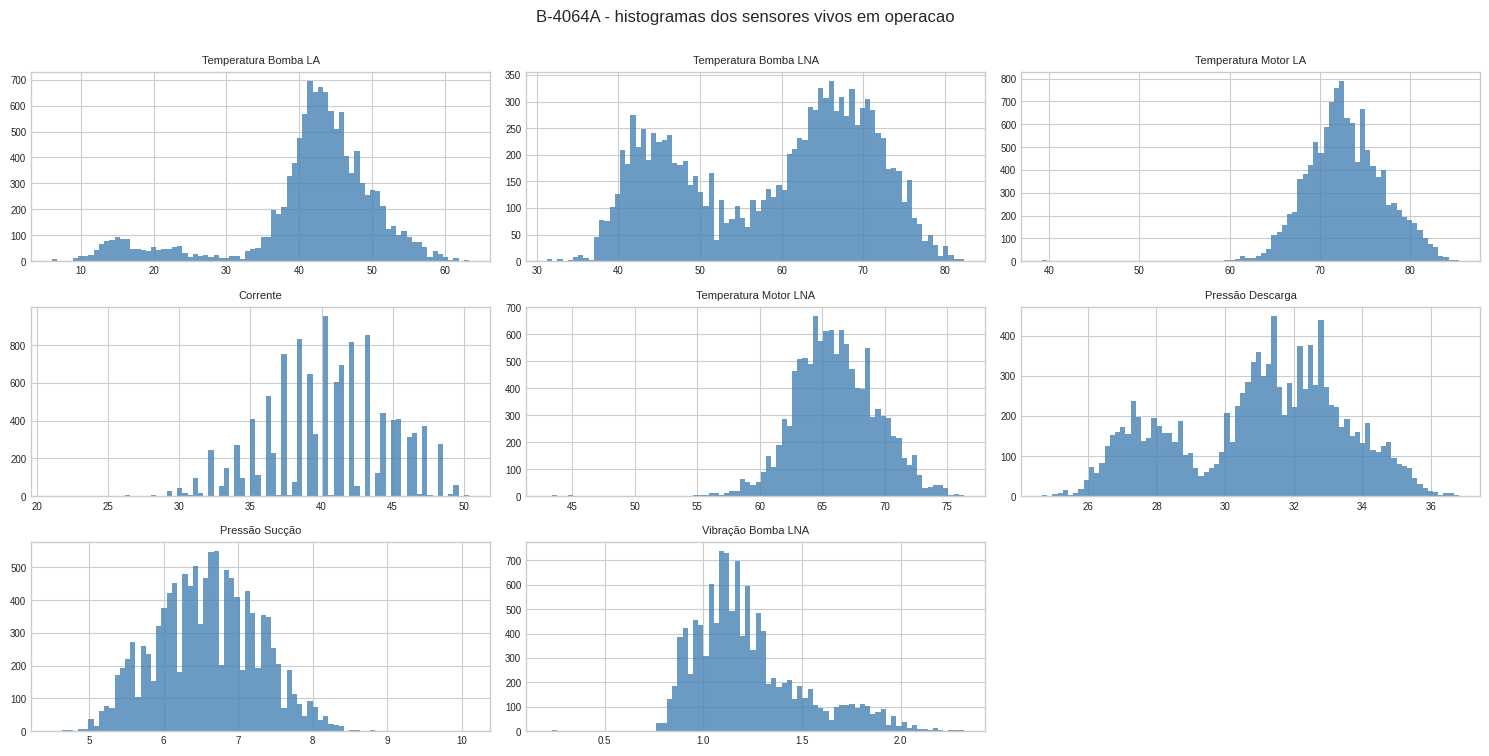

Janela normal: < 2024-08-10 07:58:00 | n=4,193
Janela pre-falha: 2024-08-27 07:58:00 -> 2024-08-30 07:58:00 | n=48


,detec_pre_falha_1pct_fp,deslocamento_robusto_sigma,normal_p50,pre_falha_p50,normal_p99,pre_falha_max
Temperatura Bomba LNA,83.3%,4.00,45.48,65.88,61.08,76.2
Vibração Bomba LNA,8.3%,2.40,1.265,1.915,2.079,2.2
Temperatura Motor LNA,6.2%,0.70,67,64.68,74.61,72.12
Corrente,0.0%,0.70,41.31,44.27,48.42,48.39
Temperatura Motor LA,0.0%,0.69,72.76,69.88,82.12,80.28
Pressão Sucção,0.0%,0.26,6.62,6.42,8.18,7.66
Pressão Descarga,0.0%,0.15,31.21,30.85,35.32,33.88
Temperatura Bomba LA,0.0%,0.01,40.04,40.12,52.29,61.48


Melhor sensor isolado @1% FP: Temperatura Bomba LNA -> deteccao 83.3%


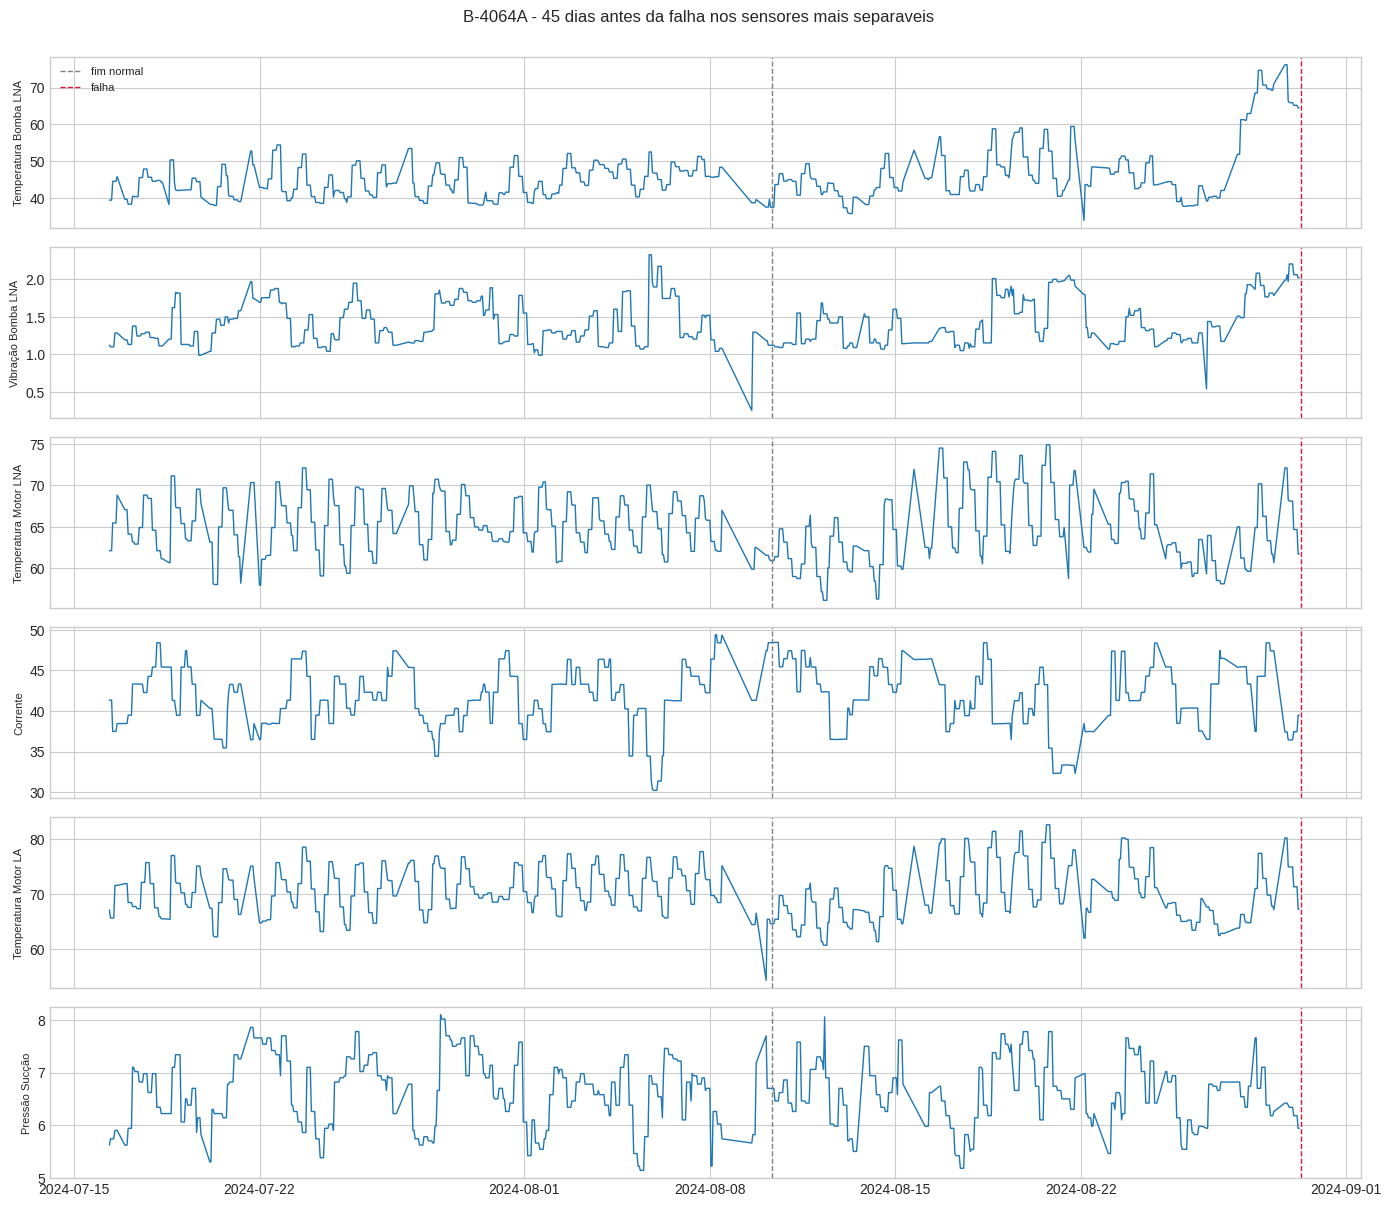

Proxy multivariado Mahalanobis @1% FP: deteccao pre-falha=93.8% | threshold=29
Pontos em operacao por ano:


,n_pontos
Timestamp,
2024,4587
2025,6240
2026,867


Maiores deslocamentos absolutos de mediana entre anos:


,max_delta_mediana
Temperatura Bomba LNA,22.239998
Temperatura Bomba LA,4.719997
Corrente,1.974194
Temperatura Motor LNA,1.599998
Temperatura Motor LA,0.880005
Vibração Bomba LNA,0.243840
Pressão Descarga,0.216000
Pressão Sucção,0.120000


In [3]:

base = proc_pre.select_dtypes(include=[np.number]) if proc_pre is not None else live
_, live2, quality2, dead2 = numeric_live(base)
if live2.empty:
    raise RuntimeError("Sem sensores vivos para diagnostico.")

act = pick_activity(live2)
cutoff, modes, off_frac, gap = activity_cutoff(live2[act])
print(f"Sensor de atividade escolhido: {act}")
if cutoff is not None:
    print(f"Bimodal ligado/desligado: modos={modes[0]:.4g}/{modes[1]:.4g}, gap={gap:.2f}, cutoff={cutoff:.4g}, desligado={off_frac:.1%}")
    operating = live2[live2[act] >= cutoff]
else:
    print("Sem bimodalidade clara para ligado/desligado; usando todos os pontos vivos.")
    operating = live2.copy()
print(f"Amostras em operacao usadas na separabilidade: {len(operating):,} ({len(operating)/max(len(live2), 1):.1%} dos pontos vivos)")

fig, ax = plt.subplots(figsize=(12, 3.5))
x = live2[act].dropna()
ax.hist(x, bins=120, color="steelblue", alpha=0.7)
if cutoff is not None:
    ax.axvline(cutoff, color="crimson", linestyle="--", label=f"cutoff={cutoff:.3g}")
ax.set_title(f"{EQUIPMENT} - histograma do sensor de atividade")
ax.set_xlabel(act)
ax.set_ylabel("contagem")
ax.legend()
plt.show()

spread = (operating.quantile(0.99) - operating.quantile(0.01)).sort_values(ascending=False)
cols = list(spread.head(min(24, len(spread))).index)
ncol = 3
nrow = int(np.ceil(len(cols) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, max(3, 2.5 * nrow)))
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, cols):
    ax.hist(operating[col].dropna(), bins=80, color="steelblue", alpha=0.8)
    ax.set_title(col, fontsize=8)
    ax.tick_params(labelsize=7)
for ax in axes[len(cols):]:
    ax.axis("off")
fig.suptitle(f"{EQUIPMENT} - histogramas dos sensores vivos em operacao", y=1.002)
fig.tight_layout()
plt.show()

normal_end_days = getattr(cfg, "normal_end_days", None) or 20
prefailure_days = getattr(cfg, "prefailure_days", None) or 7
normal_end = FAILURE_DATE - pd.Timedelta(days=normal_end_days)
pre_start = FAILURE_DATE - pd.Timedelta(days=prefailure_days)
normal = operating[operating.index < normal_end]
pre = operating[(operating.index >= pre_start) & (operating.index < FAILURE_DATE)]
print(f"Janela normal: < {normal_end} | n={len(normal):,}")
print(f"Janela pre-falha: {pre_start} -> {FAILURE_DATE} | n={len(pre):,}")

if len(normal) >= 50 and len(pre) >= 10:
    z_normal = robust_z(normal, normal).abs()
    z_pre = robust_z(pre, normal).abs()
    thr = z_normal.quantile(0.99)
    det = (z_pre > thr).mean().sort_values(ascending=False)
    shift = ((pre.median() - normal.median()).abs() / ((normal - normal.median()).abs().median().replace(0, np.nan) * 1.4826)).sort_values(ascending=False)
    sep = pd.DataFrame({
        "detec_pre_falha_1pct_fp": det,
        "deslocamento_robusto_sigma": shift,
        "normal_p50": normal.median(),
        "pre_falha_p50": pre.median(),
        "normal_p99": normal.quantile(0.99),
        "pre_falha_max": pre.max(),
    }).sort_values(["detec_pre_falha_1pct_fp", "deslocamento_robusto_sigma"], ascending=False)
    display(sep.head(20).style.format({
        "detec_pre_falha_1pct_fp": "{:.1%}",
        "deslocamento_robusto_sigma": "{:.2f}",
        "normal_p50": "{:.4g}",
        "pre_falha_p50": "{:.4g}",
        "normal_p99": "{:.4g}",
        "pre_falha_max": "{:.4g}",
    }))
    print(f"Melhor sensor isolado @1% FP: {sep.index[0]} -> deteccao {sep.iloc[0]['detec_pre_falha_1pct_fp']:.1%}")

    top = list(sep.head(min(6, len(sep))).index)
    fig, axes = plt.subplots(len(top), 1, figsize=(14, max(3, 2.0 * len(top))), sharex=True)
    axes = np.atleast_1d(axes)
    window = operating.loc[FAILURE_DATE - pd.Timedelta(days=45): FAILURE_DATE]
    for ax, col in zip(axes, top):
        ax.plot(window.index, window[col], lw=1.0)
        ax.axvline(normal_end, color="gray", linestyle="--", lw=1, label="fim normal")
        ax.axvline(FAILURE_DATE, color="crimson", linestyle="--", lw=1, label="falha")
        ax.set_ylabel(col, fontsize=8)
    axes[0].legend(loc="upper left", fontsize=8)
    fig.suptitle(f"{EQUIPMENT} - 45 dias antes da falha nos sensores mais separaveis", y=1.002)
    fig.tight_layout()
    plt.show()

    cols_model = sep.head(min(12, len(sep))).index.tolist()
    train = normal[cols_model].dropna()
    pre_m = pre[cols_model].dropna()
    if len(train) >= 50 and len(pre_m) >= 10:
        model = LedoitWolf().fit(train)
        normal_score = pd.Series(model.mahalanobis(train), index=train.index)
        pre_score = pd.Series(model.mahalanobis(pre_m), index=pre_m.index)
        mthr = float(normal_score.quantile(0.99))
        mdet = float((pre_score > mthr).mean())
        print(f"Proxy multivariado Mahalanobis @1% FP: deteccao pre-falha={mdet:.1%} | threshold={mthr:.3g}")
else:
    print("Janelas normal/pre-falha pequenas demais para estimar separabilidade de forma honesta.")

if len(operating):
    year_counts = operating.groupby(operating.index.year).size()
    print("Pontos em operacao por ano:")
    display(year_counts.to_frame("n_pontos"))
    yearly = operating.groupby(operating.index.year).median()
    if len(yearly) > 1:
        ref = yearly.iloc[0]
        delta = (yearly - ref).abs().max().sort_values(ascending=False)
        print("Maiores deslocamentos absolutos de mediana entre anos:")
        display(delta.head(15).to_frame("max_delta_mediana"))



## Leitura operacional

Use a tabela de separabilidade como um "teto" antes de treinar AutoML:

- `detec_pre_falha_1pct_fp` baixo indica que, mantendo falso positivo em torno de 1%, o sinal da
  falha quase nunca sai da distribuicao normal.
- Muitos sensores mortos/quase zerados indicam que o modo de falha nao esta coberto pela
  instrumentacao disponivel.
- Percentual alto de desligado reduz a quantidade de dados de operacao real; o modelo aprende
  muito estado parado e pouco regime saudavel.
- Deslocamento forte por ano/regime indica que o problema e re-baseline, nao hiperparametro.

Para este equipamento, o proximo passo deve ser decidido pela causa dominante acima: filtrar
estado desligado, re-baselinar no regime atual, buscar sensores do subsistema que falhou ou
descartar o caso para modelo preditivo com a instrumentacao atual.
